# Install necessary packages

In [52]:
pip install netCDF4 pandas numpy matplotlib cartopy xarray fsspec aiohttp scipy h5netcdf sqlalchemy configparser psycopg2


  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'psycopg2' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'psycopg2'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [46 lines of output]
      /Users/jonathanhachez/opt/anaconda3/envs/HVAC_climate/lib/python3.9/site-packages/setuptools/dist.py:759: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in

In [1]:

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from configparser import ConfigParser
from datetime import datetime, timedelta
import fsspec
from ftplib import FTP
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.pyplot    as plt
import netCDF4
import numpy as np
import os
import pandas as pd
from sqlalchemy import create_engine, Table, MetaData, insert
import tempfile
import xarray as xr





# List files

In [13]:

def list_ftp_dir(host: str, path: str):
    ftp = FTP(host)
    ftp.login()  # assumes anonymous or you might need credentials
    ftp.cwd(path)
    files = ftp.nlst()  # list names in current directory
    ftp.quit()
    return files

if __name__ == "__main__":
    host = "ftp.climato.be"
    path = "fettweis/MARv3.14/Belgium/full/"
    files = list_ftp_dir(host, path)
    files.remove("download.bash")
    files.remove("tas.bash")
    files.remove("ERA5")
    models = files
    print(models)
    for model in models:
        path2 = f"fettweis/MARv3.14/Belgium/full/{model}"
        print(model)
        files = list_ftp_dir(host, path2)
        ssps = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
        for ssp in ssps:
            path3 = f"fettweis/MARv3.14/Belgium/full/{model}/{ssp}"
            print(f" {ssp}")
            maps = list_ftp_dir(host, path+model+'/'+ssp)
            for Map in maps[0:5]:
                path4 = f"fettweis/MARv3.14/Belgium/full/{model}/{ssp}/{Map}"
                print(f"  {path4}")
            print(f"  ...")
            


['CMCC-CM2-SR5', 'EC-Earth3-Veg', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'NorESM2-MM']
CMCC-CM2-SR5
 ssp126
  fettweis/MARv3.14/Belgium/full/CMCC-CM2-SR5/ssp126/MARv3.14-CMCC-CM2-SR5-ssp126-2015.nc
  fettweis/MARv3.14/Belgium/full/CMCC-CM2-SR5/ssp126/MARv3.14-CMCC-CM2-SR5-ssp126-2016.nc
  fettweis/MARv3.14/Belgium/full/CMCC-CM2-SR5/ssp126/MARv3.14-CMCC-CM2-SR5-ssp126-2017.nc
  fettweis/MARv3.14/Belgium/full/CMCC-CM2-SR5/ssp126/MARv3.14-CMCC-CM2-SR5-ssp126-2018.nc
  fettweis/MARv3.14/Belgium/full/CMCC-CM2-SR5/ssp126/MARv3.14-CMCC-CM2-SR5-ssp126-2019.nc
  ...
 ssp245
  fettweis/MARv3.14/Belgium/full/CMCC-CM2-SR5/ssp245/MARv3.14-CMCC-CM2-SR5-ssp245-2015.nc
  fettweis/MARv3.14/Belgium/full/CMCC-CM2-SR5/ssp245/MARv3.14-CMCC-CM2-SR5-ssp245-2016.nc
  fettweis/MARv3.14/Belgium/full/CMCC-CM2-SR5/ssp245/MARv3.14-CMCC-CM2-SR5-ssp245-2017.nc
  fettweis/MARv3.14/Belgium/full/CMCC-CM2-SR5/ssp245/MARv3.14-CMCC-CM2-SR5-ssp245-2018.nc
  fettweis/MARv3.14/Belgium/full/CMCC-CM2-SR5/ssp245/MARv3.14-CM

# Code for animation (unecessary)

dict_keys(['CC', 'DD', 'DIST', 'EP', 'ET', 'HH', 'LAT', 'LHF', 'LON', 'LWD', 'MIN', 'MM', 'Q2m', 'RF', 'RH2m', 'RO1', 'RO2', 'RO3', 'RO4', 'RO5', 'RO6', 'RU', 'SF', 'SH', 'SHF', 'SH_MAR', 'SL', 'SLP', 'SMB', 'SN', 'SP', 'SQC', 'SQM', 'ST', 'SWD', 'SWDD', 'T2m', 'U10m', 'U2m', 'YYYY', 'ZN', 'time', 'x', 'y'])
dict_keys(['time', 'y', 'x'])
<class 'netCDF4.Dataset'>
root group (NETCDF4_CLASSIC data model, file format HDF5):
    title: Hourly MARv3.14 outputs in 2067 interpolated on the 5x5km^2 grid from IRM using CMCC-CM2-SR5-ssp245
    institution: University of Liège (Belgium)
    netcdf: 4.4.1 of Mar 21 2022 20:38:41 $
    institute: University of Liege (Belgium)
    NCO: netCDF Operators version 5.1.7 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco, DOI = 10.1016/j.envsoft.2008.03.004)
    contact: xavier.fettweis@uliege.be
    history: Mon Dec 25 12:45:17 2023: ncks -4 --cnk_dmn y,55 --cnk_dmn x,66 --cnk_dmn time,1 -L 4 out/MARv3.14-CMCC-CM2-SR5-ssp245-2067.nc out/MAR

<Figure size 1000x800 with 0 Axes>

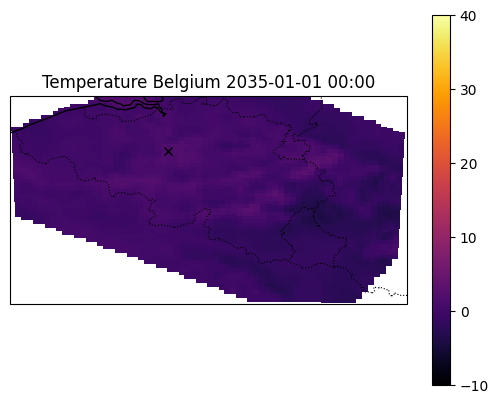

In [42]:
fp = "/Users/jonathanhachez/Downloads/MARv3.14-CMCC-CM2-SR5-ssp245-2067.nc"

nc = netCDF4.Dataset(fp)

print(nc.variables.keys())  # Lists available variables
print(nc.dimensions.keys())  # Lists dimensions
print(nc)  # Prints dataset summary

plt.figure(figsize=(10, 8))
def plot_heat_map(k):
    # k = k + 8760/3*20
    plt.clf()# Assuming nc["tas"][k,:,:] is your 2D array
    # Set up the map projection
    
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    
    t2m = nc["T2m"][k, :, :]
    lon = nc["LON"][:]  # Make sure this is the correct variable name
    lat = nc["LAT"][:]  # Make sure this is the correct variable name
    
    im = plt.pcolormesh(lon, lat, t2m, 
                     cmap="inferno",
                     vmin=-10,
                     vmax=40,
                     shading='auto')


    plt.plot(4.3572,50.8477, marker = 'x',color = 'black')
    plt.colorbar()
    
    # Add geographic features directly to current axes
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
    
    # Define the start date
    start_date = datetime(2035, 1, 1, 0, 0, 0)  # 01-01-2015 00:00:00
    
    new_date = start_date + timedelta(hours=1 * k)
    
    # Format the date for matplotlib (e.g., "2015-01-01 15:00:00")
    date_str = new_date.strftime("%Y-%m-%d %H:%M")
    
    plt.title(f"Temperature Belgium {date_str}")
    return plt

# cbar = fig.colorbar(im, ax=ax)
anim = animation.FuncAnimation(plt.figure(), plot_heat_map, interval = 10, frames = 3*24, repeat = False)
writer = animation.PillowWriter(fps = 14, metadata=dict(artist='Me'),bitrate=1800)
anim.save('unknown.gif', writer = writer)


In [14]:
def process_nc_remote(file_url: str, varname: str):
    # Download the file to a temporary location
    with tempfile.NamedTemporaryFile(suffix='.nc', delete=False) as tmp_file:
        tmp_path = tmp_file.name
    
    try:
        # Download using fsspec
        with fsspec.open(file_url, 'rb') as remote_file:
            with open(tmp_path, 'wb') as local_file:
                local_file.write(remote_file.read())
        
        # Process the local file
        # Process the local file
        ds = xr.open_dataset(tmp_path, engine='netcdf4')
        da = ds[varname]
        mean_da = da.mean(dim='time', skipna=True)
        result = mean_da.compute().values
        ds.close()
        
        return 0
    finally:
        # Clean up
        if os.path.exists(tmp_path):
            os.unlink(tmp_path)

if __name__ == "__main__":
    host = "ftp.climato.be"
    path = "fettweis/MARv3.14/Belgium/full/CMCC-CM2-SR5/ssp245"
    fname = "MARv3.14-CMCC-CM2-SR5-ssp245-2067.nc"
    file_url = f"ftp://{host}/{path}/{fname}"
    varname = "T2m"
    
    m = process_nc_remote(file_url, varname)
    print("Mean of", varname, ":", m)

Mean of T2m : 0


/Users/jonathanhachez/opt/anaconda3/envs/HVAC_climate/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [2]:
tmp_path = "/Users/jonathanhachez/Downloads/MARv3.14-CMCC-CM2-SR5-ssp245-2067.nc"
ds = xr.open_dataset(tmp_path, engine='netcdf4')
print(ds.variables)
# Extract lon/lat arrays (2D)
lons = ds["LON"].values
lats = ds["LAT"].values

# Target location
target_lon = 5.0
target_lat = 50.5

# Compute distance to every grid cell
dist = np.sqrt((lons - target_lon)**2 + (lats - target_lat)**2)

# Find nearest indices
j, i = np.unravel_index(dist.argmin(), dist.shape)
print(f"Nearest grid point: lon={lons[j,i]}, lat={lats[j,i]}")

# Extract time series of temperature at that grid point
ts = ds["CC"].isel(y=j, x=i)   # adjust dim names if different
df = ts.to_dataframe(name="value").reset_index()[["time","value"]]
df["variable"] = ds["CC"].long_name
df["ssp"] = "ssp"
df["GCM"] = "model"
df["RCM"] = "MAR"

# Reorder columns
df = df[["time","variable","ssp","GCM","value"]]

print(df.head())


Frozen({'CC': <xarray.Variable (time: 8760, y: 55, x: 66)> Size: 127MB
[31798800 values with dtype=float32]
Attributes:
    units:          -
    long_name:      Cloud Cover
    standard_name:  Cloud_Cover
    actual_range:   [0. 1.], 'DD': <xarray.Variable (time: 8760)> Size: 35kB
[8760 values with dtype=float32]
Attributes:
    units:          -
    long_name:      Day
    standard_name:  Day
    actual_range:   [ 1. 31.], 'DIST': <xarray.Variable (y: 55, x: 66)> Size: 15kB
[3630 values with dtype=float32]
Attributes:
    units:          km
    long_name:      Distance to the MAR pixel
    standard_name:  Distance_to_the_MAR_pixel
    actual_range:   [  1.      105.26425], 'EP': <xarray.Variable (time: 8760, y: 55, x: 66)> Size: 127MB
[31798800 values with dtype=float32]
Attributes:
    units:          mm/h
    long_name:      Evaporation (canopy)
    standard_name:  Evaporation__canopy_
    actual_range:   [-0.16548531  0.6415665 ], 'ET': <xarray.Variable (time: 8760, y: 55, x: 66)>

# DB configuration

In [2]:
def config(filename='db_access.ini', section='postgresql'):
    # create a parser
    parser = ConfigParser()
    # read config file
    parser.read(filename)

    # get section and update dictionary with connection string key:value pairs
    db = {}
    if section in parser:
        for key in parser[section]:
            db[key] = parser[section][key]
    else:
        raise Exception(
            'Section {0} not found in the {1} file'.format(section, filename))
    return db

# SQLAlchemy connection (for cleaner code)
def connect_SQL_alchemy():
    params = config()
    db_url = f"postgresql+psycopg2://{params['user']}:{params['password']}@{params['host']}:{params['port']}/{params['database']}"
    return create_engine(db_url)

def read_table(table_name = "belgium_res"):
    engine = connect_SQL_alchemy()
    metadata = MetaData()
    metadata.reflect(bind=engine, only = [table_name])
    table = metadata.tables.get(table_name)
    
    if table is None:
        raise ValueError(f"Table '{table_name}' not found in the database!")
    
    # 3. Fetch all data into a Pandas DataFrame
    query = table.select()  # SELECT * FROM table_name
    df = pd.read_sql(query, engine)
    return df

print(read_table(table_name = "belgium_res"))

Empty DataFrame
Columns: [longitude, latitude, time, variable, gcm, rcm, ssp, value]
Index: []


In [3]:
# Function to check if a variable is defined on the spatial grid
def is_spatial_variable(var):
    """Check if variable has spatial dimensions (y and x)"""
    dims = var.dims
    # Check if it has both spatial dimensions (adjust names if different)
    has_spatial_dims = ('y' in dims and 'x' in dims) or ('lat' in dims and 'lon' in dims)
    
    # Also check if it's not a coordinate variable
    is_coord_var = var.name in ds.coords
    
    # Check if it has time dimension (optional, depending on your needs)
    has_time_dim = 'time' in dims
    
    return has_spatial_dims and not is_coord_var

# Alternative: more specific check for your use case
def is_valid_variable_for_extraction(var, ds):
    """Check if variable is suitable for spatial extraction"""
    dims = var.dims
    
    # Skip coordinate variables
    if var.name in ds.coords:
        return False
    
    # Skip variables that don't have both spatial dimensions
    spatial_dims_present = ('y' in dims and 'x' in dims)
    if not spatial_dims_present:
        return False
    
    # Optional: also check if it has time dimension if you want time series
    # has_time_dim = 'time' in dims
    # return spatial_dims_present and has_time_dim
    
    return spatial_dims_present

def extract_variables(tmp_path, rcm, gcm, ssp, target_lon = 4.3572, target_lat = 50.8477):
    ds = xr.open_dataset(tmp_path, engine='netcdf4')
    
    # Extract lon/lat arrays (2D)
    lons = ds["LON"].values
    lats = ds["LAT"].values
    
    # Target location
    
    # Compute distance to every grid cell
    dist = np.sqrt((lons - target_lon)**2 + (lats - target_lat)**2)
    
    # Find nearest indices
    j, i = np.unravel_index(dist.argmin(), dist.shape)

    # Create a list to store all dataframes
    all_dfs = []
    
    # Process only valid spatial variables
    for varname in ds.data_vars:
        var = ds[varname]
        
        if is_valid_variable_for_extraction(var, ds):
            # Extract time series at the nearest grid point
            try:
                ts = ds[varname].isel(y=j, x=i)
                
                # Convert to dataframe
                df = ts.to_dataframe(name="value").reset_index()[["time", "value"]]
                df["variable"] = ds[varname].long_name
                df["ssp"] = ssp
                df["gcm"] = gcm
                df["rcm"] = rcm
                df["longitude"] = lons[j, i]
                df["latitude"] = lats[j, i]
                
                # Reorder columns
                df = df[["time", "variable", "ssp", "gcm", "rcm", "longitude", "latitude", "value"]]
                
                all_dfs.append(df)
                
            except Exception as e:
                print(f"Error processing {varname}: {e}")
        else:
            print(f"Skipping {varname} (not a spatial variable)")
    
    # Combine all dataframes into one
    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
    
        # Save to CSV if desired
        with connect_SQL_alchemy() as conn:
            combined_df.to_sql('belgium_res', connection = conn)
        print("Data saved to 'spatial_variables_nearest_point.csv'")
    else:
        print("No spatial variables found to extract")
    
    # Close the dataset
    ds.close()

In [11]:
def process_nc_remote(file_url: str, rcm, gcm, ssp, target_lon = 4.3572, target_lat = 50.8477):
    with tempfile.NamedTemporaryFile(suffix='.nc', delete=False) as tmp_file:
        tmp_path = tmp_file.name
    
    try:
        with fsspec.open(file_url, 'rb') as remote_file:
            with open(tmp_path, 'wb') as local_file:
                local_file.write(remote_file.read())
        
        extract_variables(tmp_path = tmp_path, rcm = 'MARv3.14', gcm = model, ssp = ssp, target_lon = 4.3572, target_lat = 50.8477)
    finally:
        if os.path.exists(tmp_path):
            os.unlink(tmp_path)


def process_ftp_dir(host: str, path: str):
    ftp = FTP(host)
    ftp.login()  # assumes anonymous or you might need credentials
    ftp.cwd(path)
    files = ftp.nlst()  # list names in current directory
    ftp.quit()
    return files

if __name__ == "__main__":
    host = "ftp.climato.be"
    path = "fettweis/MARv3.14/Belgium/full/"
    files = list_ftp_dir(host, path)
    files.remove("download.bash")
    files.remove("tas.bash")
    files.remove("ERA5")
    models = files
    for model in models:
        path2 = f"fettweis/MARv3.14/Belgium/full/{model}"
        files = list_ftp_dir(host, path2)
        ssps = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
        for ssp in ssps:
            path3 = f"fettweis/MARv3.14/Belgium/full/{model}/{ssp}"
            maps = list_ftp_dir(host, path+model+'/'+ssp)
            for Map in maps:
                path4 = f"fettweis/MARv3.14/Belgium/full/{model}/{ssp}/{Map}"
                
                host = "ftp.climato.be"
                file_url = f"ftp://{host}/{path4}"
                process_nc_remote(file_url, rcm = 'MARv3.14', gcm = model, ssp = ssp, target_lon = 4.3572, target_lat = 50.8477)
            print(f"  ...")
            


NameError: name 'ds' is not defined